
# MLPI26 Lecture 6 Supplement 2

This material is extracted from [1].

## Chapter 6 : Learning Best Practices for Model Evaluation and Hyperparameter Tuning

In the previous chapters, we learned about the essential machine learning algorithms for classification
and how to get our data into shape before we feed it into those algorithms. Now, it’s time to learn
about the best practices of building good machine learning models by fine-tuning the algorithms
and evaluating the performance of the models. In this chapter, we will learn how to do the following:

* Assess the performance of machine learning models
* Diagnose the common problems of machine learning algorithms
* Fine-tune machine learning models
* Evaluate predictive models using different performance metrics

### Streamlining workflows with pipelines

When we applied different preprocessing techniques in the previous chapters, such as standardization
for feature scaling in Chapter 4, Building Good Training Datasets – Data Preprocessing, or principal
component analysis for data compression in Chapter 5, Compressing Data via Dimensionality Reduction,
you learned that we have to reuse the parameters that were obtained during the fitting of the training
data to scale and compress any new data, such as the examples in the separate test dataset. In this
section, you will learn about an extremely handy tool, the Pipeline class in scikit-learn. It allows us
to fit a model including an arbitrary number of transformation steps and apply it to make predictions
about new data.

### Loading the Breast Cancer Wisconsin dataset

In this chapter, we will be working with the Breast Cancer Wisconsin dataset, which contains 569 examples
of malignant and benign tumor cells. The first two columns in the dataset store the unique ID
numbers of the examples and the corresponding diagnoses (M = malignant, B = benign), respectively.
Columns 3-32 contain 30 real-valued features that have been computed from digitized images of the
cell nuclei, which can be used to build a model to predict whether a tumor is benign or malignant.
The Breast Cancer Wisconsin dataset has been deposited in the UCI Machine Learning Repository,
and more detailed information about this dataset can be found at https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic).

In this section, we will read in the dataset and split it into training and test datasets in three simple steps:

1. We will start by reading in the dataset directly from the UCI website using pandas:

In [1]:
import pandas as pd

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                 'machine-learning-databases'
                 '/breast-cancer-wisconsin/wdbc.data', header=None)

# if the Breast Cancer dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df = pd.read_csv('wdbc.data', header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
df.shape

(569, 32)

2. Next, we will assign the 30 features to a NumPy array, X. Using a LabelEncoder object, we will
transform the class labels from their original string representation ('M' and 'B') into integers:

In [3]:
from sklearn.preprocessing import LabelEncoder

X = df.loc[:, 2:].values
y = df.loc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

3. After encoding the class labels (diagnosis) in an array, y, the malignant tumors are now represented
as class 1, and the benign tumors are represented as class 0, respectively. We can
double-check this mapping by calling the transform method of the fitted LabelEncoder on
two dummy class labels:

In [4]:
le.transform(['M', 'B'])

array([1, 0])

4. Before we construct our first model pipeline in the following subsection, let’s divide the dataset
into a separate training dataset (80 percent of the data) and a separate test dataset (20 percent
of the data):

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, 
                     test_size=0.20,
                     stratify=y,
                     random_state=1)

### Combining transformers and estimators in a pipeline

In the previous chapter, you learned that many learning algorithms require input features on the same
scale for optimal performance. Since the features in the Breast Cancer Wisconsin dataset are measured
on various different scales, we will standardize the columns in the Breast Cancer Wisconsin dataset
before we feed them to a linear classifier, such as logistic regression. Furthermore, let’s assume that
we want to compress our data from the initial 30 dimensions into a lower two-dimensional subspace
via principal component analysis (PCA), a feature extraction technique for dimensionality reduction
that was introduced in Chapter 5.

Instead of going through the model fitting and data transformation steps for the training and test
datasets separately, we can chain the StandardScaler, PCA, and LogisticRegression objects in a
pipeline:

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression())

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
test_acc = pipe_lr.score(X_test, y_test)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.956


The make_pipeline function takes an arbitrary number of scikit-learn transformers (objects that support
the fit and transform methods as input), followed by a scikit-learn estimator that implements the
fit and predict methods. In our preceding code example, we provided two scikit-learn transformers,
StandardScaler and PCA, and a LogisticRegression estimator as inputs to the make_pipeline function,
which constructs a scikit-learn Pipeline object from these objects.

We can think of a scikit-learn Pipeline as a meta-estimator or wrapper around those individual
transformers and estimators. If we call the fit method of Pipeline, the data will be passed down a
series of transformers via fit and transform calls on these intermediate steps until it arrives at the
estimator object (the final element in a pipeline). The estimator will then be fitted to the transformed
training data.

When we executed the fit method on the pipe_lr pipeline in the preceding code example,
StandardScaler first performed fit and transform calls on the training data. Second, the transformed
training data was passed on to the next object in the pipeline, PCA. Similar to the previous
step, PCA also executed fit and transform on the scaled input data and passed it to the final element
of the pipeline, the estimator.

Finally, the LogisticRegression estimator was fit to the training data after it underwent transformations
via StandardScaler and PCA. Again, we should note that there is no limit to the number of
intermediate steps in a pipeline; however, if we want to use the pipeline for prediction tasks, the last
pipeline element has to be an estimator.

Similar to calling fit on a pipeline, pipelines also implement a predict method if the last step in the
pipeline is an estimator. If we feed a dataset to the predict call of a Pipeline object instance, the data
will pass through the intermediate steps via transform calls. In the final step, the estimator object
will then return a prediction on the transformed data.

The pipelines of the scikit-learn library are immensely useful wrapper tools that we will use frequently
throughout the rest of this book. To make sure that you’ve got a good grasp of how the Pipeline object
works, please take a close look at Figure 6.1, which summarizes our discussion from the previous
paragraphs:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_01.png" width=800 />

Figure 6.1: The inner workings of the Pipeline object

### Using k-fold cross-validation to assess model performance

In this section, you will learn about the common cross-validation techniques holdout cross-validation
and k-fold cross-validation, which can help us to obtain reliable estimates of the model’s generalization
performance, that is, how well the model performs on unseen data.

### The holdout method

A classic and popular approach for estimating the generalization performance of machine learning
models is the holdout method. Using the holdout method, we split our initial dataset into separate
training and test datasets—the former is used for model training, and the latter is used to estimate its
generalization performance. However, in typical machine learning applications, we are also interested
in tuning and comparing different parameter settings to further improve the performance for
making predictions on unseen data. This process is called model selection, with the name referring
to a given classification problem for which we want to select the optimal values of tuning parameters
(also called hyperparameters). However, if we reuse the same test dataset over and over again during
model selection, it will become part of our training data and thus the model will be more likely to
overfit. Despite this issue, many people still use the test dataset for model selection, which is not a
good machine learning practice.

A better way of using the holdout method for model selection is to separate the data into three parts:
a training dataset, a validation dataset, and a test dataset. The training dataset is used to fit the different
models, and the performance on the validation dataset is then used for model selection. The
advantage of having a test dataset that the model hasn’t seen before during the training and model
selection steps is that we can obtain a less biased estimate of its ability to generalize to new data. Figure
6.2 illustrates the concept of holdout cross-validation, where we use a validation dataset to repeatedly
evaluate the performance of the model after training using different hyperparameter values. Once
we are satisfied with the tuning of hyperparameter values, we estimate the model’s generalization
performance on the test dataset:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_02.png" width=800 />

Figure 6.2: How to use training, validation, and test datasets

A disadvantage of the holdout method is that the performance estimate may be very sensitive to how
we partition the training dataset into the training and validation subsets; the estimate will vary for
different examples of the data. In the next subsection, we will take a look at a more robust technique
for performance estimation, k-fold cross-validation, where we repeat the holdout method k times on
k subsets of the training data.

### K-fold cross-validation

In k-fold cross-validation, we randomly split the training dataset into k folds without replacement.
Here, k – 1 folds, the so-called training folds, are used for the model training, and one fold, the so-called
test fold, is used for performance evaluation. This procedure is repeated k times so that we obtain k
models and performance estimates.

___

**Sampling with and without replacement**

We looked at an example to illustrate sampling with and without replacement in Chapter
3. If you haven’t read that chapter, or want a refresher, refer to the information box titled
Sampling with and without replacement in the Combining multiple decision trees via random
forests section.

___

We then calculate the average performance of the models based on the different, independent test
folds to obtain a performance estimate that is less sensitive to the sub-partitioning of the training data
compared to the holdout method. Typically, we use k-fold cross-validation for model tuning, that is,
finding the optimal hyperparameter values that yield a satisfying generalization performance, which
is estimated from evaluating the model performance on the test folds.

Once we have found satisfactory hyperparameter values, we can retrain the model on the complete
training dataset and obtain a final performance estimate using the independent test dataset. The
rationale behind fitting a model to the whole training dataset after k-fold cross-validation is that first,
we are typically interested in a single, final model (versus k individual models), and second, providing
more training examples to a learning algorithm usually results in a more accurate and robust model.

Since k-fold cross-validation is a resampling technique without replacement, the advantage of this
approach is that in each iteration, each example will be used exactly once, and the training and test
folds are disjoint. Furthermore, all test folds are disjoint; that is, there is no overlap between the
test folds. Figure 6.3 summarizes the concept behind k-fold cross-validation with k = 10. The training
dataset is divided into 10 folds, and during the 10 iterations, 9 folds are used for training, and 1 fold
will be used as the test dataset for model evaluation.

Also, the estimated performances, Ei (for example, classification accuracy or error), for each fold are
then used to calculate the estimated average performance, E, of the model:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_03.png" width=800 />

Figure 6.3: How k-fold cross-validation works

In summary, k-fold cross-validation makes better use of the dataset than the holdout method with a
validation set, since in k-fold cross-validation all data points are being used for evaluation.

A good standard value for k in k-fold cross-validation is 10, as empirical evidence shows. For instance,
experiments by Ron Kohavi on various real-world datasets suggest that 10-fold cross-validation offers
the best tradeoff between bias and variance (A Study of Cross-Validation and Bootstrap for Accuracy Estimation
and Model Selection by Kohavi, Ron, International Joint Conference on Artificial Intelligence (IJCAI),
14 (12): 1137-43, 1995, https://www.ijcai.org/Proceedings/95-2/Papers/016.pdf).

However, if we are working with relatively small training sets, it can be useful to increase the number
of folds. If we increase the value of k, more training data will be used in each iteration, which results
in a lower pessimistic bias toward estimating the generalization performance by averaging the individual
model estimates. However, large values of k will also increase the runtime of the cross-validation
algorithm and yield estimates with higher variance, since the training folds will be more similar to
each other. On the other hand, if we are working with large datasets, we can choose a smaller value
for k, for example, k = 5, and still obtain an accurate estimate of the average performance of the model
while reducing the computational cost of refitting and evaluating the model on the different folds.

___

**Leave-one-out cross-validation**

A special case of k-fold cross-validation is the leave-one-out cross-validation (LOOCV)
method. In LOOCV, we set the number of folds equal to the number of training examples
(k = n) so that only one training example is used for testing during each iteration, which
is a recommended approach for working with very small datasets.

___

A slight improvement over the standard k-fold cross-validation approach is stratified k-fold cross-validation,
which can yield better bias and variance estimates, especially in cases of unequal class proportions,
which has also been shown in the same study by Ron Kohavi referenced previously in this
section. In stratified cross-validation, the class label proportions are preserved in each fold to ensure
that each fold is representative of the class proportions in the training dataset, which we will illustrate
by using the StratifiedKFold iterator in scikit-learn:

In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
    

kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)

scores = []
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)

    print(f'Fold: {k+1:02d}, '
          f'Class distr.: {np.bincount(y_train[train])}, '
          f'Acc.: {score:.3f}')
    
mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f'\nCV accuracy: {mean_acc:.3f} +/- {std_acc:.3f}')

Fold: 01, Class distr.: [256 153], Acc.: 0.935
Fold: 02, Class distr.: [256 153], Acc.: 0.935
Fold: 03, Class distr.: [256 153], Acc.: 0.957
Fold: 04, Class distr.: [256 153], Acc.: 0.957
Fold: 05, Class distr.: [256 153], Acc.: 0.935
Fold: 06, Class distr.: [257 153], Acc.: 0.956
Fold: 07, Class distr.: [257 153], Acc.: 0.978
Fold: 08, Class distr.: [257 153], Acc.: 0.933
Fold: 09, Class distr.: [257 153], Acc.: 0.956
Fold: 10, Class distr.: [257 153], Acc.: 0.956

CV accuracy: 0.950 +/- 0.014


First, we initialized the StratifiedKFold iterator from the sklearn.model_selection module with
the y_train class labels in the training dataset, and we specified the number of folds via the n_splits
parameter. When we used the kfold iterator to loop through the k folds, we used the returned indices
in train to fit the logistic regression pipeline that we set up at the beginning of this chapter. Using the
pipe_lr pipeline, we ensured that the examples were scaled properly (for instance, standardized) in
each iteration. We then used the test indices to calculate the accuracy score of the model, which we
collected in the scores list to calculate the average accuracy and the standard deviation of the estimate.

Although the previous code example was useful to illustrate how k-fold cross-validation works, scikitlearn
also implements a k-fold cross-validation scorer, which allows us to evaluate our model using
stratified k-fold cross-validation less verbosely:

In [8]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print(f'CV accuracy scores: {scores}')
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 +/- 0.014


An extremely useful feature of the cross_val_score approach is that we can distribute the evaluation
of the different folds across multiple central processing units (CPUs) on our machine. If we set
the n_jobs parameter to 1, only one CPU will be used to evaluate the performances, just like in our
StratifiedKFold example previously. However, by setting n_jobs=2, we could distribute the 10 rounds
of cross-validation to two CPUs (if available on our machine), and by setting n_jobs=-1, we can use
all available CPUs on our machine to do the computation in parallel.

____

**Estimating generalization performance**

Please note that a detailed discussion of how the variance of the generalization performance
is estimated in cross-validation is beyond the scope of this book, but you can refer
to a comprehensive article about model evaluation and cross-validation (Model Evaluation,
Model Selection, and Algorithm Selection in Machine Learning by S. Raschka), which we
share at https://arxiv.org/abs/1811.12808. This article also discusses alternative
cross-validation techniques, such as the .632 and .632+ bootstrap cross-validation methods.
In addition, you can find a detailed discussion in an excellent article by M. Markatou and
others (Analysis of Variance of Cross-validation Estimators of the Generalization Error by M.
Markatou, H. Tian, S. Biswas, and G. M. Hripcsak, Journal of Machine Learning Research, 6: 1127-
1168, 2005), which is available at https://www.jmlr.org/papers/v6/markatou05a.html.

___

### Debugging algorithms with learning and validation curves

In this section, we will take a look at two very simple yet powerful diagnostic tools that can help us to
improve the performance of a learning algorithm: learning curves and validation curves. In the next
subsections, we will discuss how we can use learning curves to diagnose whether a learning algorithm
has a problem with overfitting (high variance) or underfitting (high bias). Furthermore, we will take
a look at validation curves, which can help us to address the common issues of learning algorithms.

#### Diagnosing bias and variance problems with learning curves

If a model is too complex for a given training dataset—for example, think of a very deep decision
tree—the model tends to overfit the training data and does not generalize well to unseen data. Often,
it can help to collect more training examples to reduce the degree of overfitting.

However, in practice, it can often be very expensive or simply not feasible to collect more data. By
plotting the model training and validation accuracies as functions of the training dataset size, we can
easily detect whether the model suffers from high variance or high bias, and whether the collection
of more data could help to address this problem.

But before we discuss how to plot learning curves in scikit-learn, let’s discuss those two common
model issues by walking through the following illustration:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_04.png" width=800 />

Figure 6.4: Common model issues

The graph in the upper left shows a model with a high bias. This model has both low training and
cross-validation accuracy, which indicates that it underfits the training data. Common ways to address
this issue are to increase the number of model parameters, for example, by collecting or constructing
additional features, or by decreasing the degree of regularization, for example, in support vector
machine (SVM) or logistic regression classifiers.

The graph in the upper-right shows a model that suffers from high variance, which is indicated by the
large gap between the training and cross-validation accuracy. To address this problem of overfitting,
we can collect more training data, reduce the complexity of the model, or increase the regularization
parameter, for example.

For unregularized models, it can also help to decrease the number of features via feature selection
(Chapter 4) or feature extraction (Chapter 5) to decrease the degree of overfitting. While collecting more
training data usually tends to decrease the chance of overfitting, it may not always help, for example,
if the training data is extremely noisy or the model is already very close to optimal.

In the next subsection, we will see how to address those model issues using validation curves, but let’s
first see how we can use the learning curve function from scikit-learn to evaluate the model:


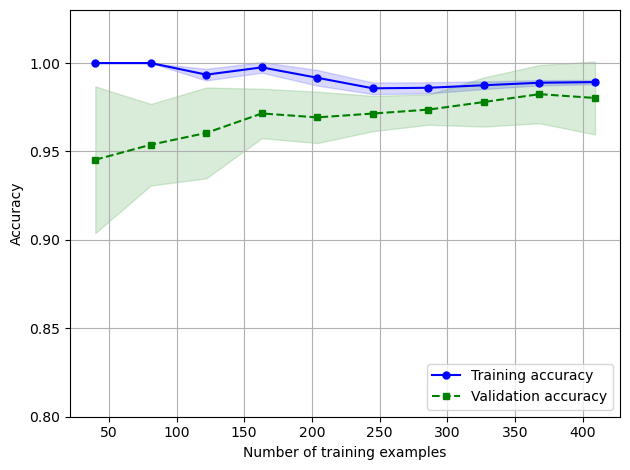

In [9]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(penalty='l2', max_iter=10000))

train_sizes, train_scores, test_scores =\
                learning_curve(estimator=pipe_lr,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
# plt.savefig('figures/06_05.png', dpi=300)
plt.show()

Figure 6.5: A learning curve showing training and validation dataset accuracy by the number of
training examples

Note that we passed max_iter=10000 as an additional argument when instantiating the
LogisticRegression object (which uses 1,000 iterations as a default) to avoid convergence issues for
the smaller dataset sizes or extreme regularization parameter values (covered in the next section). After
we have successfully executed the preceding code, we will obtain the  learning curve plot as in Figure 6.5.

Via the train_sizes parameter in the learning_curve function, we can control the absolute or
relative number of training examples that are used to generate the learning curves. Here, we set
train_sizes=np.linspace(0.1, 1.0, 10) to use 10 evenly spaced, relative intervals for the training
dataset sizes. By default, the learning_curve function uses stratified k-fold cross-validation to calculate
the cross-validation accuracy of a classifier, and we set k = 10 via the cv parameter for 10-fold
stratified cross-validation.

Then, we simply calculated the average accuracies from the returned cross-validated training and
test scores for the different sizes of the training dataset, which we plotted using Matplotlib’s plot
function. Furthermore, we added the standard deviation of the average accuracy to the plot using the
fill_between function to indicate the variance of the estimate.

As we can see in the preceding learning curve plot, our model performs quite well on both the training
and validation datasets if it has seen more than 250 examples during training. We can also see that the
training accuracy increases for training datasets with fewer than 250 examples, and the gap between
validation and training accuracy widens—an indicator of an increasing degree of overfitting.

#### Addressing over- and underfitting with validation curves

Validation curves are a useful tool for improving the performance of a model by addressing issues such
as overfitting or underfitting. Validation curves are related to learning curves, but instead of plotting
the training and test accuracies as functions of the sample size, we vary the values of the model parameters,
for example, the inverse regularization parameter, C, in logistic regression.

Let’s go ahead and see how we create validation curves via scikit-learn. Using the code below, we obtained the validation curve plot for the parameter C:

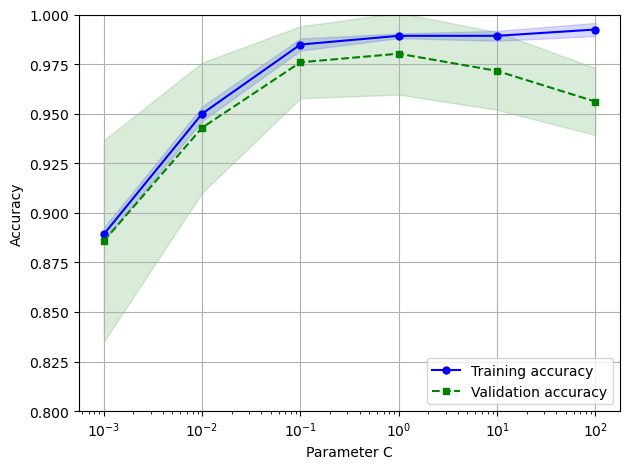

In [10]:
from sklearn.model_selection import validation_curve


param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
                estimator=pipe_lr, 
                X=X_train, 
                y=y_train, 
                param_name='logisticregression__C', 
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(param_range, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(param_range, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.tight_layout()
# plt.savefig('figures/06_06.png', dpi=300)
plt.show()

Figure 6.6: A validation curve plot for the SVM hyperparameter C

Similar to the learning_curve function, the validation_curve function uses stratified k-fold cross-validation
by default to estimate the performance of the classifier. Inside the validation_curve function,
we specified the parameter that we wanted to evaluate. In this case, it is C, the inverse regularization
parameter of the LogisticRegression classifier, which we wrote as 'logisticregression__C' to access
the LogisticRegression object inside the scikit-learn pipeline for a specified value range that we
set via the param_range parameter. Similar to the learning curve example in the previous section, we
plotted the average training and cross-validation accuracies and the corresponding standard deviations.

Although the differences in the accuracy for varying values of C are subtle, we can see that the model
slightly underfits the data when we increase the regularization strength (small values of C). However,
for large values of C, it means lowering the strength of regularization, so the model tends to slightly
overfit the data. In this case, the sweet spot appears to be between 0.1 and 1.0 of the C value.

### Fine-tuning machine learning models via grid search

In machine learning, we have two types of parameters: those that are learned from the training data,
for example, the weights in logistic regression, and the parameters of a learning algorithm that are optimized
separately. The latter are the tuning parameters (or hyperparameters) of a model, for example,
the regularization parameter in logistic regression or the maximum depth parameter of a decision tree.

In the previous section, we used validation curves to improve the performance of a model by tuning
one of its hyperparameters. In this section, we will take a look at a popular hyperparameter optimization
technique called grid search, which can further help to improve the performance of a model
by finding the optimal combination of hyperparameter values.

#### Tuning hyperparameters via grid search

The grid search approach is quite simple: it’s a brute-force exhaustive search paradigm where we specify
a list of values for different hyperparameters, and the computer evaluates the model performance
for each combination to obtain the optimal combination of values from this set:

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))

param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [{'svc__C': param_range, 
               'svc__kernel': ['linear']},
              {'svc__C': param_range, 
               'svc__gamma': param_range, 
               'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc, 
                  param_grid=param_grid, 
                  scoring='accuracy', 
                  refit=True,
                  cv=10)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


Using the preceding code, we initialized a GridSearchCV object from the sklearn.model_selection
module to train and tune an SVM pipeline. We set the param_grid parameter of GridSearchCV to a list
of dictionaries to specify the parameters that we’d want to tune. For the linear SVM, we only evaluated
the inverse regularization parameter, C; for the radial basis function (RBF) kernel SVM, we tuned both
the svc__C and svc__gamma parameters. Note that the svc__gamma parameter is specific to kernel SVMs.

GridSearchCV uses k-fold cross-validation for comparing models trained with different hyperparameter
settings. Via the cv=10 setting, it will carry out 10-fold cross-validation and compute the average
accuracy (via scoring='accuracy') across these 10-folds to assess the model performance. We set
n_jobs=-1 so that GridSearchCV can use all our processing cores to speed up the grid search by fitting
models to the different folds in parallel, but if your machine has problems with this setting, you may
change this setting to n_jobs=None for single processing.

After we used the training data to perform the grid search, we obtained the score of the best-performing
model via the best_score_ attribute and looked at its parameters, which can be accessed via the
best_params_ attribute. In this particular case, the RBF kernel SVM model with svc__C = 100.0
yielded the best k-fold cross-validation accuracy: 98.5 percent.

Finally, we use the independent test dataset to estimate the performance of the best-selected model,
which is available via the best_estimator_ attribute of the GridSearchCV object:

In [12]:
clf = gs.best_estimator_

# clf.fit(X_train, y_train) 
# note that we do not need to refit the classifier
# because this is done automatically via refit=True.

print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

Test accuracy: 0.974


Please note that fitting a model with the best settings (gs.best_estimator_) on the training set manually
via clf.fit(X_train, y_train) after completing the grid search is not necessary. The GridSearchCV
class has a refit parameter, which will refit the gs.best_estimator_ to the whole training set automatically
if we set refit=True (default).

### Exploring hyperparameter configurations more widely with randomized search

Since grid search is an exhaustive search, it is guaranteed to find the optimal hyperparameter configuration
if it is contained in the user-specified parameter grid. However, specifying large hyperparameter
grids makes grid search very expensive in practice. An alternative approach for sampling different
parameter combinations is randomized search. In randomized search, we draw hyperparameter
configurations randomly from distributions (or discrete sets). In contrast to grid search, randomized
search does not do an exhaustive search over the hyperparameter space. Still, it allows us to explore a
wider range of hyperparameter value settings in a more cost- and time-effective manner. This concept
is illustrated in Figure 6.7, which shows a fixed grid of nine hyperparameter settings being searched
via grid search and randomized search:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_11.png" width=800 />

Figure 6.7: A comparison of grid search and randomized search for sampling nine different hyperparameter
configurations each

The main takeaway is that while grid search only explores discrete, user-specified choices, it may
miss good hyperparameter configurations if the search space is too scarce. Interested readers can
find additional details about randomized search, along with empirical studies, in the following article:
Random Search for Hyper-Parameter Optimization by J. Bergstra, Y. Bengio, Journal of Machine Learning
Research, pp. 281-305, 2012, https://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.

Let’s look at how we can use randomized search for tuning an SVM. Scikit-learn implements a
RandomizedSearchCV class, which is analogous to the GridSearchCV we used in the previous subsection.
The main difference is that we can specify distributions as part of our parameter grid and specify
the total number of hyperparameter configurations to be evaluated. For example, let’s consider the
hyperparameter range we used for several hyperparameters when tuning the SVM in the grid search
example in the previous section:

In [13]:
import scipy.stats
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

Note that while RandomizedSearchCV can accept similar discrete lists of values as inputs for the parameter
grid, which is useful when considering categorical hyperparameters, its main power lies in
the fact that we can replace these lists with distributions to sample from. Thus, for example, we may
substitute the preceding list with the following distribution from SciPy:

In [14]:
param_range = scipy.stats.loguniform(0.0001, 1000.0)

For instance, using a loguniform distribution instead of a regular uniform distribution will ensure
that in a sufficiently large number of trials, the same number of samples will be drawn from the
[0.0001, 0.001] range as, for example, the [10.0, 100.0] range. To check its behavior, we can draw 10
random samples from this distribution via the rvs(10) method, as shown here:

In [15]:
np.random.seed(1)
param_range.rvs(10)

array([8.30145146e-02, 1.10222804e+01, 1.00184520e-04, 1.30715777e-02,
       1.06485687e-03, 4.42965766e-04, 2.01289666e-03, 2.62376594e-02,
       5.98924832e-02, 5.91176467e-01])

___
**Specifying distributions** 

RandomizedSearchCV supports arbitrary distributions as long as we can sample from
them by calling the rvs() method. A list of all distributions currently available via scipy.
stats can be found here: https://docs.scipy.org/doc/scipy/reference/stats.html#probability-distributions.
___

Let’s now see the RandomizedSearchCV in action and tune an SVM as we did with GridSearchCV in
the previous section:

In [16]:
from sklearn.model_selection import RandomizedSearchCV

pipe_svc = make_pipeline(
    StandardScaler(),
    SVC(random_state=1))

param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
              {'svc__C': param_range,
               'svc__gamma': param_range,
               'svc__kernel': ['rbf']}]


rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_grid,
                        scoring='accuracy',
                        refit=True,
                        n_iter=20,
                        cv=10,
                        random_state=1,
                        n_jobs=-1)

In [17]:
rs = rs.fit(X_train, y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9780676328502416
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


Based on this code example, we can see that the usage is very similar to GridSearchCV, except that we
could use distributions for specifying parameter ranges and specified the number of iterations—20
iterations—by setting n_iter=20.

### More resource-efficient hyperparameter search with successive halving

Taking the idea of randomized search one step further, scikit-learn implements a successive halving
variant, HalvingRandomSearchCV, that makes finding suitable hyperparameter configurations more
efficient. Successive halving, given a large set of candidate configurations, successively throws out
unpromising hyperparameter configurations until only one configuration remains. We can summarize
the procedure via the following steps:

1. Draw a large set of candidate configurations via random sampling
2. Train the models with limited resources, for example, a small subset of the training data (as
opposed to using the entire training set)
3. Discard the bottom 50 percent based on predictive performance
4. Go back to step 2 with an increased amount of available resources

The steps are repeated until only one hyperparameter configuration remains. Note that there is also
a successive halving implementation for the grid search variant called HalvingGridSearchCV, where
all specified hyperparameter configurations are used in step 1 instead of random samples.

In scikit-learn 1.0, HalvingRandomSearchCV is still experimental, which is why we have to enable it first:

In [18]:
from sklearn.experimental import enable_halving_search_cv

(The above code may not work or be supported in future releases.)

After enabling the experimental support, we can use randomized search with successive halving as
shown in the following:



In [19]:
from sklearn.model_selection import HalvingRandomSearchCV

hs = HalvingRandomSearchCV(
    pipe_svc,
    param_distributions=param_grid,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1)

The resource='n_samples' (default) setting specifies that we consider the training set size as the resource
we vary between the rounds. Via the factor parameter, we can determine how many candidates
are eliminated in each round. For example, setting factor=2 eliminates half of the candidates, and setting
factor=1.5 means that only 100%/1.5 ≈ 66% of the candidates make it into the next round. Instead
of choosing a fixed number of iterations as in RandomizedSearchCV, we set n_candidates='exhaust'
(default), which will sample the number of hyperparameter configurations such that the maximum
number of resources (here: training examples) are used in the last round.

We can then carry out the search similar to RandomizedSearchCV:

In [20]:
hs = hs.fit(X_train, y_train)
print(hs.best_score_)
print(hs.best_params_)

0.9617647058823529
{'svc__C': np.float64(4.934834261073333), 'svc__kernel': 'linear'}


In [21]:
clf = hs.best_estimator_
print(f'Test accuracy: {hs.score(X_test, y_test):.3f}')

Test accuracy: 0.982


If we compare the results from GridSearchCV and RandomizedSearchCV from the previous two subsections
with the model from HalvingRandomSearchCV, we can see that the latter yields a model that
performs slightly better on the test set (98.2 percent accuracy as opposed to 97.4 percent).

___
**Hyperparameter tuning with hyperopt** 

Another popular library for hyperparameter optimization is hyperopt (https://github.com/hyperopt/hyperopt), which implements several different methods for hyperparameter
optimization, including randomized search and the Tree-structured Parzen Estimators
(TPE) method. TPE is a Bayesian optimization method based on a probabilistic
model that is continuously updated based on past hyperparameter evaluations and the
associated performance scores instead of regarding these evaluations as independent
events. You can find out more about TPE in Algorithms for Hyper-Parameter Optimization.
Bergstra J, Bardenet R, Bengio Y, Kegl B. NeurIPS 2011. pp. 2546–2554, https://dl.acm.org/doi/10.5555/2986459.2986743.

While hyperopt provides a general-purpose interface for hyperparameter optimization,
there is also a scikit-learn-specific package called hyperopt-sklearn for additional convenience:
https://github.com/hyperopt/hyperopt-sklearn.

___

### Algorithm selection with nested cross-validation

Using k-fold cross-validation in combination with grid search or randomized search is a useful approach
for fine-tuning the performance of a machine learning model by varying its hyperparameter
values, as we saw in the previous subsections. If we want to select among different machine
learning algorithms, though, another recommended approach is nested cross-validation. In a nice
study on the bias in error estimation, Sudhir Varma and Richard Simon concluded that the true
error of the estimate is almost unbiased relative to the test dataset when nested cross-validation is
used (Bias in Error Estimation When Using Cross-Validation for Model Selection by S. Varma and R. Simon,
BMC Bioinformatics, 7(1): 91, 2006, https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-7-91).

In nested cross-validation, we have an outer k-fold cross-validation loop to split the data into training
and test folds, and an inner loop is used to select the model using k-fold cross-validation on the training
fold. After model selection, the test fold is then used to evaluate the model performance. Figure 6.8
explains the concept of nested cross-validation with only five outer and two inner folds, which can
be useful for large datasets where computational performance is important; this particular type of
nested cross-validation is also known as 5×2 cross-validation:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_07.png" width=800 />

Figure 6.8: The concept of nested cross-validation

In scikit-learn, we can perform nested cross-validation with grid search as follows:

In [22]:
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_grid = [{'svc__C': param_range,
 'svc__kernel': ['linear']},
 {'svc__C': param_range,
 'svc__gamma': param_range,
 'svc__kernel': ['rbf']}]

In [23]:
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train, 
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy: 0.974 +/- 0.015


The returned average cross-validation accuracy gives us a good estimate of what to expect if we tune
the hyperparameters of a model and use it on unseen data.

For example, we can use the nested cross-validation approach to compare an SVM model to a simple
decision tree classifier; for simplicity, we will only tune its depth parameter:

In [24]:
from sklearn.tree import DecisionTreeClassifier

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train, 
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')

CV accuracy: 0.934 +/- 0.016


### Looking at different performance evaluation metrics

In the previous sections and chapters, we evaluated different machine learning models using prediction
accuracy, which is a useful metric with which to quantify the performance of a model in general.
However, there are several other performance metrics that can be used to measure a model’s relevance,
such as precision, recall, the F1 score, and Matthews correlation coefficient (MCC).

#### Reading a confusion matrix

Before we get into the details of different scoring metrics, let’s take a look at a confusion matrix, a
matrix that lays out the performance of a learning algorithm.

A confusion matrix is simply a square matrix that reports the counts of the true positive (TP), true negative
(TN), false positive (FP), and false negative (FN) predictions of a classifier, as shown in Figure 6.9:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch06/figures/06_08.png" width=600 />

Figure 6.9: The confusion matrix

Although these metrics can be easily computed manually by comparing the actual and predicted class
labels, scikit-learn provides a convenient confusion_matrix function that we can use, as follows:

In [25]:
from sklearn.metrics import confusion_matrix

pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


The array that was returned after executing the code provides us with information about the different
types of error the classifier made on the test dataset. We can map this information onto the confusion
matrix illustration in Figure 6.9 using Matplotlib’s matshow function:

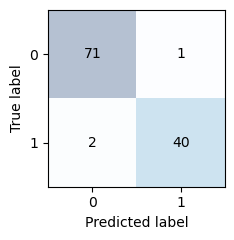

In [26]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
#plt.savefig('figures/06_09.png', dpi=300)
plt.show()

Figure 6.10: A confusion matrix for our data

Assuming that class 1 (malignant) is the positive class in this example, our model correctly classified
71 of the examples that belong to class 0 (TN) and 40 examples that belong to class 1 (TP), respectively.
However, our model also incorrectly misclassified two examples from class 1 as class 0 (FN), and it
predicted that one example is malignant although it is a benign tumor (FP). In the next subsection,
we will learn how we can use this information to calculate various error metrics.

___
### Additional Note

Remember that we previously encoded the class labels so that *malignant* examples are the "postive" class (1), and *benign* examples are the "negative" class (0):

In [28]:
le.transform(['M', 'B'])

array([1, 0])

Next, we printed the confusion matrix like so:

In [29]:
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


Note that the (true) class 0 examples that are correctly predicted as class 0 (true negatives) are now in the upper left corner of the matrix (index 0, 0). In order to change the ordering so that the true negatives are in the lower right corner (index 1,1) and the true positves are in the upper left, we can use the `labels` argument like shown below:

In [30]:
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=[1, 0])
print(confmat)

[[40  2]
 [ 1 71]]


We conclude:

Assuming that class 1 (malignant) is the positive class in this example, our model correctly classified 71 of the examples that belong to class 0 (true negatives) and 40 examples that belong to class 1 (true positives), respectively. However, our model also incorrectly misclassified 1 example from class 0 as class 1 (false positive), and it predicted that 2 examples are benign although it is a malignant tumor (false negatives).

___

### Optimizing the precision and recall of a classification model

Both the prediction **error (ERR)** and **accuracy (ACC)** provide general information about how many
examples are misclassified. The error can be understood as the sum of all false predictions divided
by the number of total predictions, and the accuracy is calculated as the sum of correct predictions
divided by the total number of predictions, respectively:
$$
ERR = \frac{FP + FN}{FP + FN + TP + TN}
$$
The prediction accuracy can then be calculated directly from the error:
$$
ACC = \frac{TP+TN}{FP+FN+TP+TN} = 1 - ERR
$$
The **true positive rate (TPR)** and **false positive rate (FPR)** are performance metrics that are especially
useful for imbalanced class problems:
$$
FPR = \frac{FP}{N} = \frac{FP}{FP+TN}
$$
$$
TPR = \frac{TP}{P} = \frac{TP}{FN+TP}
$$
In tumor diagnosis, for example, we are more concerned about the detection of malignant tumors
in order to help a patient with the appropriate treatment. However, it is also important to decrease
the number of benign tumors incorrectly classified as malignant (FP) to not unnecessarily concern
patients. In contrast to the FPR, the TPR provides useful information about the fraction of positive (or
relevant) examples that were correctly identified out of the total pool of positives (P).

The performance metrics **precision (PRE)** and **recall (REC)** are related to those TP and TN rates, and
in fact, REC is synonymous with TPR:
$$
REC = TPR = \frac{TP}{P} = \frac{TP}{FN+TP}
$$
In other words, recall quantifies how many of the relevant records (the positives) are captured as such
(the true positives). Precision quantifies how many of the records predicted as relevant (the sum of
true and false positives) are actually relevant (true positives):
$$
PRE = \frac{TP}{TP+FP}
$$
Revisiting the malignant tumor detection example, optimizing for recall helps with minimizing the
chance of not detecting a malignant tumor. However, this comes at the cost of predicting malignant
tumors in patients although the patients are healthy (a high number of FPs). If we optimize for precision,
on the other hand, we emphasize correctness if we predict that a patient has a malignant tumor.
However, this comes at the cost of missing malignant tumors more frequently (a high number of FNs).

To balance the up- and downsides of optimizing PRE and REC, the harmonic mean of PRE and REC
is used, the so-called F1 score:
$$
F1 = 2\frac{PRE \times REC}{PRE + REC}
$$
___

**Further reading on precision and recall**

If you are interested in a more thorough discussion of the different performance metrics,
such as precision and recall, read David M. W. Powers’ technical report Evaluation: From
Precision, Recall and F-Factor to ROC, Informedness, Markedness & Correlation, which is freely
available at https://arxiv.org/abs/2010.16061.
___

Lastly, a measure that summarizes a confusion matrix is the MCC, which is especially popular in
biological research contexts. The MCC is calculated as follows:
$$
MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$
In contrast to PRE, REC, and the F1 score, the MCC ranges between –1 and 1, and it takes all elements
of a confusion matrix into account—for instance, the F1 score does not involve the TN. While the MCC
values are harder to interpret than the F1 score, it is regarded as a superior metric, as described in the
following article: The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy
in binary classification evaluation by D. Chicco and G. Jurman, BMC Genomics. pp. 281-305, 2012, https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-019-6413-7.


Those scoring metrics are all implemented in scikit-learn and can be imported from the sklearn.
metrics module as shown in the following snippet:


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import matthews_corrcoef

pre_val = precision_score(y_true=y_test, y_pred=y_pred)
print(f'Precision: {pre_val:.3f}')

rec_val = recall_score(y_true=y_test, y_pred=y_pred)
print(f'Recall: {rec_val:.3f}')

f1_val = f1_score(y_true=y_test, y_pred=y_pred)
print(f'F1: {f1_val:.3f}')

mcc_val = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'MCC: {mcc_val:.3f}')

Precision: 0.976
Recall: 0.952
F1: 0.964
MCC: 0.943


Furthermore, we can use a different scoring metric than accuracy in the GridSearchCV via the scoring
parameter. A complete list of the different values that are accepted by the scoring parameter can be
found at http://scikit-learn.org/stable/modules/model_evaluation.html.

Remember that the positive class in scikit-learn is the class that is labeled as class 1. If we want to
specify a different positive label, we can construct our own scorer via the make_scorer function, which
we can then directly provide as an argument to the scoring parameter in GridSearchCV (in this example,
using the f1_score as a metric):

In [32]:
from sklearn.metrics import make_scorer

scorer = make_scorer(f1_score, pos_label=0)

c_gamma_range = [0.01, 0.1, 1.0, 10.0]

param_grid = [{'svc__C': c_gamma_range,
               'svc__kernel': ['linear']},
              {'svc__C': c_gamma_range,
               'svc__gamma': c_gamma_range,
               'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring=scorer,
                  cv=10,
                  n_jobs=-1)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9861994953378878
{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


### Plotting a receiver operating characteristic

Receiver operating characteristic (ROC) graphs are useful tools to select models for classification
based on their performance with respect to the FPR and TPR, which are computed by shifting the
decision threshold of the classifier. The diagonal of a ROC graph can be interpreted as random guessing,
and classification models that fall below the diagonal are considered as worse than random guessing.
A perfect classifier would fall into the top-left corner of the graph with a TPR of 1 and an FPR of 0.
Based on the ROC curve, we can then compute the so-called **ROC area under the curve (ROC AUC)** to
characterize the performance of a classification model.

Similar to ROC curves, we can compute precision-recall curves for different probability thresholds
of a classifier. A function for plotting those precision-recall curves is also implemented in scikit-learn
and is documented at http://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html. 

Executing the following code example, we will plot a ROC curve of a classifier that only uses two features
from the Breast Cancer Wisconsin dataset to predict whether a tumor is benign or malignant.
Although we are going to use the same logistic regression pipeline that we defined previously, we
are only using two features this time. This is to make the classification task more challenging for the
classifier, by withholding useful information contained in the other features, so that the resulting
ROC curve becomes visually more interesting. For similar reasons, we are also reducing the number
of folds in the StratifiedKFold validator to three. The code is as follows:

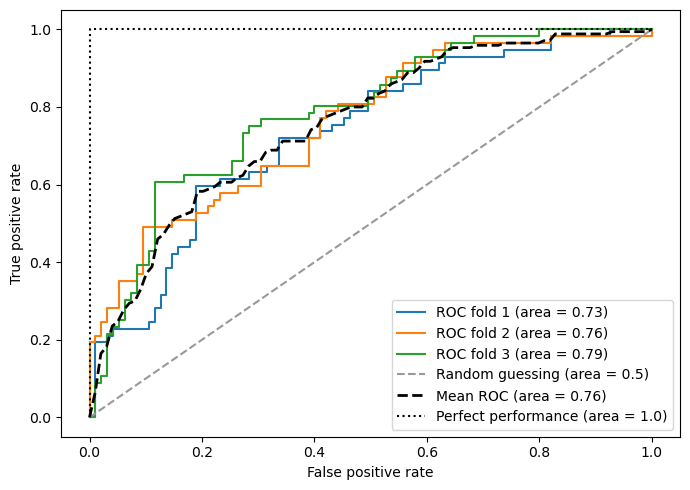

In [ ]:
from sklearn.metrics import roc_curve, auc
from numpy import interp

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression(penalty='l2', 
                                           random_state=1,
                                           solver='lbfgs',
                                           C=100.0))

X_train2 = X_train[:, [4, 14]]
    
cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))

fig = plt.figure(figsize=(7, 5))

mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2[train],
                         y_train[train]).predict_proba(X_train2[test])

    fpr, tpr, thresholds = roc_curve(y_train[test],
                                     probas[:, 1],
                                     pos_label=1)
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,
             tpr,
             label=f'ROC fold {i+1} (area = {roc_auc:.2f})')

plt.plot([0, 1],
         [0, 1],
         linestyle='--',
         color=(0.6, 0.6, 0.6),
         label='Random guessing (area = 0.5)')

mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, 'k--',
         label=f'Mean ROC (area = {mean_auc:.2f})', lw=2)
plt.plot([0, 0, 1],
         [0, 1, 1],
         linestyle=':',
         color='black',
         label='Perfect performance (area = 1.0)')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Figure 6.11: The ROC plot

In the preceding code example, we used the already familiar StratifiedKFold class from scikit-learn
and calculated the ROC performance of the LogisticRegression classifier in our pipe_lr pipeline
using the roc_curve function from the sklearn.metrics module separately for each iteration. Furthermore,
we interpolated the average ROC curve from the three folds via the interp function that
we imported from NumPy and calculated the area under the curve via the auc function. The resulting
ROC curve indicates that there is a certain degree of variance between the different folds, and the
average ROC AUC (0.76) falls between a perfect score (1.0) and random guessing (0.5):

Note that if we are just interested in the ROC AUC score, we could also directly import the roc_auc_
score function from the sklearn.metrics submodule, which can be used similarly to the other scoring
functions (for example, precision_score) that were introduced in the previous sections.

Reporting the performance of a classifier as the ROC AUC can yield further insights into a classifier’s
performance with respect to imbalanced samples. However, while the accuracy score can be interpreted
as a single cutoff point on a ROC curve, A. P. Bradley showed that the ROC AUC and accuracy
metrics mostly agree with each other: The Use of the Area Under the ROC Curve in the Evaluation of Machine
Learning Algorithms by A. P. Bradley, Pattern Recognition, 30(7): 1145-1159, 1997, https://reader.elsevier.com/reader/sd/pii/S0031320396001422.

### Scoring metrics for multiclass classification

The scoring metrics that we’ve discussed so far are specific to binary classification systems. However,
scikit-learn also implements macro and micro averaging methods to extend those scoring metrics
to multiclass problems via **one-vs.-all (OvA)** classification. The micro-average is calculated from the
individual TPs, TNs, FPs, and FNs of the system. For example, the micro-average of the precision score
in a k-class system can be calculated as follows:
$$
PRE_{micro} = \frac{TP_1 + \ldots + TP_k}{TP_1 + \ldots + TP_k + FP_1 + \ldots + FP_k}
$$
The macro-average is simply calculated as the average scores of the different systems:
$$
PRE_{macro} = \frac{PRE_1 + \ldots + PRE_k}{k}
$$

Micro-averaging is useful if we want to weight each instance or prediction equally, whereas macro-averaging
weights all classes equally to evaluate the overall performance of a classifier with regard to
the most frequent class labels.

If we are using binary performance metrics to evaluate multiclass classification models in scikit-learn,
a normalized or weighted variant of the macro-average is used by default. The weighted macro-average
is calculated by weighting the score of each class label by the number of true instances when
calculating the average. The weighted macro-average is useful if we are dealing with class imbalances,
that is, different numbers of instances for each label.

While the weighted macro-average is the default for multiclass problems in scikit-learn, we can specify
the averaging method via the average parameter inside the different scoring functions that we import
from the sklearn.metrics module, for example, the precision_score or make_scorer functions:

In [34]:
pre_scorer = make_scorer(score_func=precision_score, 
                         pos_label=1, 
                         greater_is_better=True, 
                         average='micro')

### Dealing with class imbalance

We’ve mentioned class imbalances several times throughout this chapter, and yet we haven’t actually
discussed how to deal with such scenarios appropriately if they occur. Class imbalance is a quite common
problem when working with real-world data—examples from one class or multiple classes are
over-represented in a dataset. We can think of several domains where this may occur, such as spam
filtering, fraud detection, or screening for diseases.

Imagine that the Breast Cancer Wisconsin dataset that we’ve been working with in this chapter consisted
of 90 percent healthy patients. In this case, we could achieve 90 percent accuracy on the test
dataset by just predicting the majority class (benign tumor) for all examples, without the help of a
supervised machine learning algorithm. Thus, training a model on such a dataset that achieves approximately
90 percent test accuracy would mean our model hasn’t learned anything useful from the
features provided in this dataset.

In this section, we will briefly go over some of the techniques that could help with imbalanced datasets.
But before we discuss different methods to approach this problem, let’s create an imbalanced
dataset from our dataset, which originally consisted of 357 benign tumors (class 0) and 212 malignant
tumors (class 1):

In [35]:
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

In this code snippet, we took all 357 benign tumor examples and stacked them with the first 40 malignant
examples to create a stark class imbalance. If we were to compute the accuracy of a model
that always predicts the majority class (benign, class 0), we would achieve a prediction accuracy of
approximately 90 percent:

In [36]:
y_pred = np.zeros(y_imb.shape[0])
np.mean(y_pred == y_imb) * 100

np.float64(89.92443324937027)

Thus, when we fit classifiers on such datasets, it would make sense to focus on other metrics than
accuracy when comparing different models, such as precision, recall, the ROC curve—whatever we
care most about in our application. For instance, our priority might be to identify the majority of patients
with malignant cancer to recommend an additional screening, so recall should be our metric of
choice. In spam filtering, where we don’t want to label emails as spam if the system is not very certain,
precision might be a more appropriate metric.

Aside from evaluating machine learning models, class imbalance influences a learning algorithm
during model fitting itself. Since machine learning algorithms typically optimize a reward or loss
function that is computed as a sum over the training examples that it sees during fitting, the decision
rule is likely going to be biased toward the majority class.

In other words, the algorithm implicitly learns a model that optimizes the predictions based on the
most abundant class in the dataset to minimize the loss or maximize the reward during training.

One way to deal with imbalanced class proportions during model fitting is to assign a larger penalty
to wrong predictions on the minority class. Via scikit-learn, adjusting such a penalty is as convenient
as setting the class_weight parameter to class_weight='balanced', which is implemented for most
classifiers.

Other popular strategies for dealing with class imbalance include upsampling the minority class,
downsampling the majority class, and the generation of synthetic training examples. Unfortunately,
there’s no universally best solution or technique that works best across different problem domains.
Thus, in practice, it is recommended to try out different strategies on a given problem, evaluate the
results, and choose the technique that seems most appropriate.

The scikit-learn library implements a simple resample function that can help with the upsampling of
the minority class by drawing new samples from the dataset with replacement. The following code
will take the minority class from our imbalanced Breast Cancer Wisconsin dataset (here, class 1) and
repeatedly draw new samples from it until it contains the same number of examples as class label 0:

In [37]:
from sklearn.utils import resample

print('Number of class 1 examples before:', X_imb[y_imb == 1].shape[0])

X_upsampled, y_upsampled = resample(X_imb[y_imb == 1],
                                    y_imb[y_imb == 1],
                                    replace=True,
                                    n_samples=X_imb[y_imb == 0].shape[0],
                                    random_state=123)

print('Number of class 1 examples after:', X_upsampled.shape[0])

Number of class 1 examples before: 40
Number of class 1 examples after: 357


After resampling, we can then stack the original class 0 samples with the upsampled class 1 subset to
obtain a balanced dataset as follows:

In [38]:
X_bal = np.vstack((X[y == 0], X_upsampled))
y_bal = np.hstack((y[y == 0], y_upsampled))

Consequently, a majority vote prediction rule would only achieve 50 percent accuracy:

In [39]:
y_pred = np.zeros(y_bal.shape[0])
np.mean(y_pred == y_bal) * 100

np.float64(50.0)

Similarly, we could downsample the majority class by removing training examples from the dataset.
To perform downsampling using the resample function, we could simply swap the class 1 label with
class 0 in the previous code example and vice versa.

___
**Generating new training data to address class imbalance**

Another technique for dealing with class imbalance is the generation of synthetic training
examples, which is beyond the scope of this book. Probably the most widely used algorithm
for synthetic training data generation is Synthetic Minority Over-sampling Technique
(SMOTE), and you can learn more about this technique in the original research article by
Nitesh Chawla and others: SMOTE: Synthetic Minority Over-sampling Technique, Journal of
Artificial Intelligence Research, 16: 321-357, 2002, which is available at https://www.jair.org/index.php/jair/article/view/10302. It is also highly recommended to check
out imbalanced-learn, a Python library that is entirely focused on imbalanced datasets,
including an implementation of SMOTE. You can learn more about imbalanced-learn at
https://github.com/scikit-learn-contrib/imbalanced-learn.

___

### Summary

At the beginning of this chapter, we discussed how to chain different transformation techniques and
classifiers in convenient model pipelines that help us to train and evaluate machine learning models
more efficiently. We then used those pipelines to perform k-fold cross-validation, one of the essential
techniques for model selection and evaluation. Using k-fold cross-validation, we plotted learning
and validation curves to diagnose common problems of learning algorithms, such as overfitting and
underfitting.

Using grid search, randomized search, and successive halving, we further fine-tuned our model. We
then used confusion matrices and various performance metrics to evaluate and optimize a model’s
performance for specific problem tasks. Finally, we concluded this chapter by discussing different
methods for dealing with imbalanced data, which is a common problem in many real-world applications.
Now, you should be well equipped with the essential techniques to build supervised machine
learning models for classification successfully.

In the next chapter, we will look at ensemble methods: methods that allow us to combine multiple
models and classification algorithms to boost the predictive performance of a machine learning
system even further.


### Related Video

<ul>
<li />Sebastian Raschka : <a href="https://youtube.com/playlist?list=PLTKMiZHVd_2KyGirGEvKlniaWeLOHhUF3&si=-PIf5PD_GvH6C7GS">Intro to Machine Learning</a> 2021

</ul>

### Reference

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022. [Github](https://github.com/rasbt/machine-learning-book)

